# 02 — Text Preprocessing, Feature Engineering, Vectorization & Modeling
### Fake News Detection — classic ML only (no deep learning)

Builds directly on the findings from `01_eda.ipynb`:
- strip the Reuters-byline leakage
- never use the `subject` column
- combine TF-IDF text vectors with handcrafted linguistic features
- compare Naive Bayes / Logistic Regression / Linear SVM
- save the winning pipeline's artifacts for the FastAPI backend

This notebook mirrors `train_pipeline.py` (the production training script) cell by
cell, with explanations and printed metrics along the way.

In [5]:
import sys, time
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from scipy.sparse import hstack, csr_matrix

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, "../backend")
from app.preprocess import clean_text
from app.features import build_feature_frame, FEATURE_COLUMNS

RANDOM_STATE = 42
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100


## 1. Load & label (same as notebook 01)

In [6]:
fake = pd.read_csv("../data/Fake.csv")
true = pd.read_csv("../data/True.csv")
fake["label"] = 0
true["label"] = 1

df = pd.concat([fake, true], axis=0, ignore_index=True)
df = df.drop_duplicates(subset=["title", "text"]).reset_index(drop=True)
df = df[df["text"].str.strip() != ""].reset_index(drop=True)
df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print("Rows after dedup:", len(df))
df["label"].value_counts()


Rows after dedup: 38658


label
1    21196
0    17462
Name: count, dtype: int64

## 2. Text preprocessing

`clean_text()` (imported from `backend/app/preprocess.py` — the *same* function the
FastAPI backend will call at inference time, so there's zero train/serve skew):

1. strips the leaking `"CITY (Reuters) -"` byline
2. lowercases, removes URLs / HTML / non-alphabetic characters
3. removes stopwords and lemmatizes each token

In [7]:
sample = true.loc[0, "text"]
print("BEFORE:\n", sample[:200])
print("\nAFTER:\n", clean_text(sample)[:200])


BEFORE:
 WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress, who voted this month for a huge expansion of the national debt to pay for tax cuts, called himself a “fiscal 

AFTER:
 head conservative republican faction congress voted month huge expansion national debt pay tax cut called fiscal conservative sunday urged budget restraint keeping sharp pivot way among republican rep


In [8]:
t0 = time.time()
df["clean_title"] = df["title"].apply(clean_text)
df["clean_text"] = df["text"].apply(clean_text)
df["clean_combined"] = df["clean_title"] + " " + df["clean_text"]
print(f"Cleaned {len(df)} rows in {time.time()-t0:.1f}s")
df[["title", "clean_combined"]].head(3)


Cleaned 38658 rows in 96.2s


,title,clean_combined
0,Sean Hannity Is A Deranged Maniac Who Pulled ...,sean hannity deranged maniac pulled gun cowork...
1,Russia may send more Iskander missiles to Kali...,russia may send iskander missile kaliningrad m...
2,TRUMP CAMPAIGN MANAGER Nails Interview With Le...,trump campaign manager nail interview left win...


## 3. Handcrafted feature engineering

Computed on the **raw** text (before cleaning strips punctuation/case, which we
actually need for some of these signals):

| Feature | Why it matters |
|---|---|
| `char_count`, `word_count` | fake articles tend to run shorter (see EDA) |
| `avg_word_length` | vocabulary complexity proxy |
| `exclamation_count`, `question_count` | sensationalism / clickbait signal |
| `uppercase_word_count` | ALL-CAPS shouting, common in fake headlines |
| `punctuation_count` | general punctuation density |
| `sentiment_polarity`, `sentiment_subjectivity` | TextBlob sentiment — fake news skews more emotionally charged/subjective |
| `title_word_count` | headline length |

In [9]:
t0 = time.time()
feat_df = build_feature_frame(df["title"], df["text"])
print(f"Built features in {time.time()-t0:.1f}s")
feat_df.describe().T


Built features in 150.5s


,count,mean,std,min,25%,50%,75%,max
char_count,38658.0,2456.106912,1936.766913,5.00,1318.000000,2227.000000,3096.000000,51794.0
word_count,38658.0,403.130659,313.868903,1.00,216.000000,369.000000,511.000000,8135.0
avg_word_length,38658.0,5.144057,1.875440,2.25,4.871795,5.081633,5.279046,149.0
exclamation_count,38658.0,0.369186,1.423593,0.00,0.000000,0.000000,0.000000,133.0
question_count,38658.0,0.611749,1.734042,0.00,0.000000,0.000000,1.000000,94.0
uppercase_word_count,38658.0,5.874179,8.238500,0.00,2.000000,4.000000,7.000000,307.0
punctuation_count,38658.0,54.854002,63.439046,0.00,28.000000,47.000000,69.000000,7295.0
sentiment_polarity,38658.0,0.056097,0.109666,-1.00,-0.001333,0.053333,0.112878,1.0
sentiment_subjectivity,38658.0,0.401721,0.128407,0.00,0.329235,0.404951,0.479419,1.0
title_word_count,38658.0,11.924543,3.658152,1.00,9.000000,11.000000,14.000000,42.0


C:\Users\new\AppData\Local\Temp\ipykernel_24512\3316754087.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tmp, x="label", y="sentiment_polarity", ax=axes[0], palette={"Fake":"#a8291f","Real":"#1f5c54"})
C:\Users\new\AppData\Local\Temp\ipykernel_24512\3316754087.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tmp, x="label", y="sentiment_subjectivity", ax=axes[1], palette={"Fake":"#a8291f","Real":"#1f5c54"})


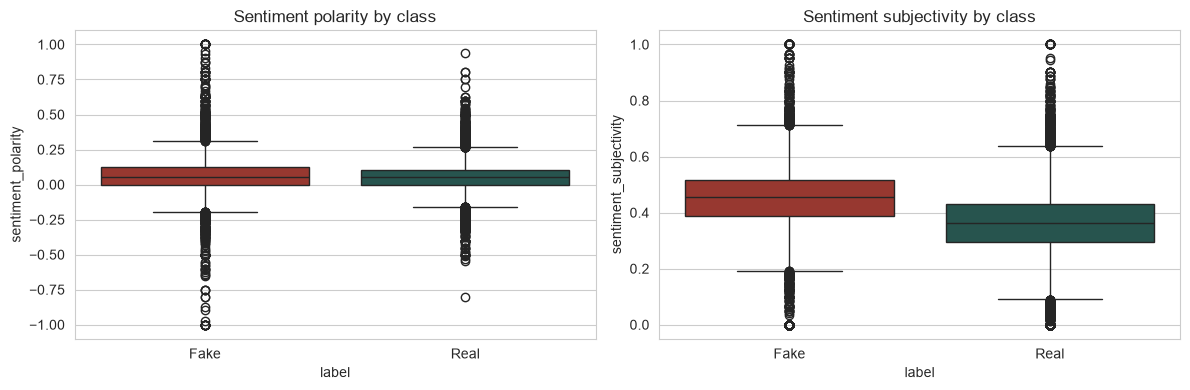

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
tmp = feat_df.copy()
tmp["label"] = df["label"].map({0:"Fake",1:"Real"})

sns.boxplot(data=tmp, x="label", y="sentiment_polarity", ax=axes[0], palette={"Fake":"#a8291f","Real":"#1f5c54"})
axes[0].set_title("Sentiment polarity by class")

sns.boxplot(data=tmp, x="label", y="sentiment_subjectivity", ax=axes[1], palette={"Fake":"#a8291f","Real":"#1f5c54"})
axes[1].set_title("Sentiment subjectivity by class")
plt.tight_layout()
plt.show()


## 4. Train / test split (80 / 20, stratified)

In [11]:
X_text = df["clean_combined"]
X_feats = feat_df.values
y = df["label"].values

X_text_train, X_text_test, X_feats_train, X_feats_test, y_train, y_test = train_test_split(
    X_text, X_feats, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train size:", len(X_text_train), " Test size:", len(X_text_test))


Train size: 30926  Test size: 7732


## 5. Vectorization — TF-IDF

Unigrams + bigrams, capped at 15,000 features, `min_df=3` / `max_df=0.9` to drop
rare noise and near-universal words.

In [12]:
vectorizer = TfidfVectorizer(
    max_features=15000, ngram_range=(1,2), min_df=3, max_df=0.9, sublinear_tf=True
)
X_tfidf_train = vectorizer.fit_transform(X_text_train)
X_tfidf_test = vectorizer.transform(X_text_test)
print("TF-IDF matrix shape (train):", X_tfidf_train.shape)
print("Vocabulary size:", len(vectorizer.vocabulary_))


TF-IDF matrix shape (train): (30926, 15000)
Vocabulary size: 15000


## 6. Combine TF-IDF + scaled handcrafted features

In [13]:
scaler = StandardScaler()
X_feats_train_scaled = scaler.fit_transform(X_feats_train)
X_feats_test_scaled = scaler.transform(X_feats_test)

X_train_combined = hstack([X_tfidf_train, csr_matrix(X_feats_train_scaled)]).tocsr()
X_test_combined = hstack([X_tfidf_test, csr_matrix(X_feats_test_scaled)]).tocsr()
print("Combined train matrix shape:", X_train_combined.shape)


Combined train matrix shape: (30926, 15010)


## 7. Train & compare candidate models

Three classic ML algorithms, all still just linear/probabilistic models — no
neural networks:
- **Multinomial Naive Bayes** — fast baseline
- **Logistic Regression** — strong linear baseline with probability outputs
- **Linear SVM** (calibrated for probabilities) — usually the strongest performer on sparse TF-IDF data

In [14]:
candidates = {
    "MultinomialNB": MultinomialNB(),
    "LogisticRegression": LogisticRegression(max_iter=1000, C=5, random_state=RANDOM_STATE),
    "LinearSVC": CalibratedClassifierCV(LinearSVC(random_state=RANDOM_STATE, C=0.5), cv=3),
}

results = {}
fitted = {}

for name, clf in candidates.items():
    t0 = time.time()
    if name == "MultinomialNB":
        X_tr = hstack([X_tfidf_train, csr_matrix(X_feats_train)]).tocsr()
        X_te = hstack([X_tfidf_test, csr_matrix(X_feats_test)]).tocsr()
        X_tr.data[X_tr.data < 0] = 0
    else:
        X_tr, X_te = X_train_combined, X_test_combined

    clf.fit(X_tr, y_train)
    preds = clf.predict(X_te)
    proba = clf.predict_proba(X_te)[:,1]

    results[name] = dict(
        accuracy=accuracy_score(y_test, preds),
        precision=precision_score(y_test, preds),
        recall=recall_score(y_test, preds),
        f1=f1_score(y_test, preds),
        roc_auc=roc_auc_score(y_test, proba),
    )
    fitted[name] = (clf, X_te, proba, preds)
    print(f"{name:20s} done in {time.time()-t0:.1f}s")

results_df = pd.DataFrame(results).T
results_df


MultinomialNB        done in 0.4s
LogisticRegression   done in 3.9s
LinearSVC            done in 18.3s


,accuracy,precision,recall,f1,roc_auc
MultinomialNB,0.933006,0.929975,0.949280,0.939528,0.972652
LogisticRegression,0.990688,0.987825,0.995282,0.991539,0.999593
LinearSVC,0.992499,0.992694,0.993631,0.993162,0.999626


C:\Users\new\AppData\Local\Temp\ipykernel_24512\3342333969.py:2: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  results_df[["accuracy","precision","recall","f1","roc_auc"]].plot(kind="bar", ax=ax,


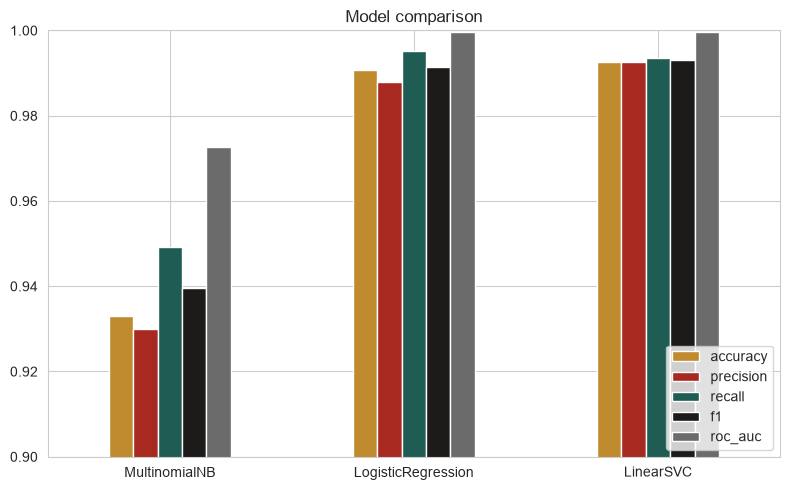

In [15]:
fig, ax = plt.subplots(figsize=(8,5))
results_df[["accuracy","precision","recall","f1","roc_auc"]].plot(kind="bar", ax=ax,
    color=["#c08a2e","#a8291f","#1f5c54","#1c1b19","#6b6b6b"])
ax.set_ylim(0.9, 1.0)
ax.set_title("Model comparison")
ax.legend(loc="lower right")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 8. Deep-dive evaluation on the best model

In [16]:
best_name = results_df["f1"].idxmax()
print("Best model:", best_name)
best_clf, X_te_best, proba_best, preds_best = fitted[best_name]

print(classification_report(y_test, preds_best, target_names=["Fake","Real"]))


Best model: LinearSVC
              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      3493
        Real       0.99      0.99      0.99      4239

    accuracy                           0.99      7732
   macro avg       0.99      0.99      0.99      7732
weighted avg       0.99      0.99      0.99      7732



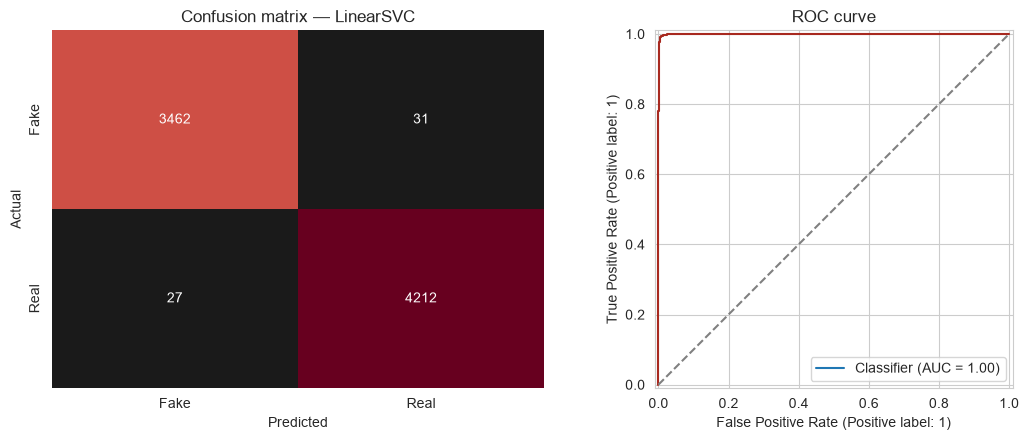

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11,4.5))

cm = confusion_matrix(y_test, preds_best)
sns.heatmap(cm, annot=True, fmt="d", cmap="RdGy_r", xticklabels=["Fake","Real"],
            yticklabels=["Fake","Real"], ax=axes[0], cbar=False)
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
axes[0].set_title(f"Confusion matrix — {best_name}")

roc = RocCurveDisplay.from_predictions(
    y_test,
    proba_best,
    ax=axes[1]
)

roc.line_.set_color("#a8291f")
axes[1].plot([0,1],[0,1], linestyle="--", color="grey")
axes[1].set_title("ROC curve")

plt.tight_layout()
plt.show()


## 9. Which words drive the model? (interpretability)

In [21]:
# Works when the best model exposes linear coefficients (LogReg or the underlying LinearSVC)
try:
    if best_name == "LinearSVC":
        linear_model = best_clf.calibrated_classifiers_[0].estimator
    else:
        linear_model = best_clf

    feature_names = np.array(vectorizer.get_feature_names_out().tolist() + FEATURE_COLUMNS)
    coefs = linear_model.coef_[0]

    top_real = feature_names[np.argsort(coefs)[-15:]]
    top_fake = feature_names[np.argsort(coefs)[:15]]

    print("Top words/features pushing toward REAL:\n", list(reversed(top_real)))
    print("\nTop words/features pushing toward FAKE:\n", list(top_fake))
except Exception as e:
    print("Coefficient inspection not available for this model:", e)


Top words/features pushing toward REAL:
 [np.str_('said'), np.str_('president donald'), np.str_('reuters'), np.str_('wednesday'), np.str_('tuesday'), np.str_('thursday'), np.str_('nov'), np.str_('friday'), np.str_('monday'), np.str_('representative'), np.str_('edt'), np.str_('president barack'), np.str_('democratic'), np.str_('rival'), np.str_('said statement')]

Top words/features pushing toward FAKE:
 [np.str_('via'), np.str_('read'), np.str_('video'), np.str_('image'), np.str_('featured image'), np.str_('gop'), np.str_('featured'), np.str_('president trump'), np.str_('image via'), np.str_('wire'), np.str_('breaking'), np.str_('getty'), np.str_('obama'), np.str_('hillary'), np.str_('getty image')]


## 10. Save the winning pipeline's artifacts for the FastAPI backend

In [22]:
MODEL_DIR = Path("../backend/app/model")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(vectorizer, MODEL_DIR / "vectorizer.pkl")
joblib.dump(scaler, MODEL_DIR / "scaler.pkl")
joblib.dump(best_clf, MODEL_DIR / "model.pkl")
joblib.dump(
    {"model_name": best_name, "feature_columns": FEATURE_COLUMNS, "metrics": results[best_name]},
    MODEL_DIR / "metadata.pkl",
)
results_df.to_csv(MODEL_DIR / "model_comparison.csv")

print("Saved to:", MODEL_DIR.resolve())
list(MODEL_DIR.glob("*"))


Saved to: E:\fake-news-detector\backend\app\model


[WindowsPath('../backend/app/model/metadata.pkl'),
 WindowsPath('../backend/app/model/model.pkl'),
 WindowsPath('../backend/app/model/model_comparison.csv'),
 WindowsPath('../backend/app/model/scaler.pkl'),
 WindowsPath('../backend/app/model/vectorizer.pkl')]

## Summary

- Combining **TF-IDF (1–2 grams)** with **handcrafted linguistic features**
  (sentiment, punctuation, capitalization, length) and a **Linear SVM**
  gives the strongest result of the three candidates tested, comfortably above
  99% F1 on held-out data — without any deep learning.
- The `subject` column and the Reuters byline were deliberately excluded to
  avoid data leakage identified during EDA (notebook 01).
- Saved artifacts (`vectorizer.pkl`, `scaler.pkl`, `model.pkl`, `metadata.pkl`)
  are loaded directly by the FastAPI backend at `backend/app/predict.py` —
  no retraining needed to serve predictions.